In [ ]:
""" Created on April 24, 2026 // @author: Sarah Shi """

import numpy as np
import mineralML as mm

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# Interactive Tools for Mapped EDS Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SarahShi/mineralML/blob/main/docs/examples/mineralML_interactive.ipynb)

This notebook demonstrates **interactive tools for exploring mineralML phase maps**. These tools require a live Python kernel and an interactive Matplotlib backend — they cannot be run on ReadTheDocs. Use the Colab badge above or run locally with `%matplotlib widget` (requires `ipympl`).

```bash
pip install ipympl
```

The tools shown here are:

- **`mm.interactive_pixels`** — click pixels to sample oxide compositions
- **`mm.interactive_line_profile`** — click to draw transects and extract line profiles
- **`mm.plot_locations`** — plot the locations of picked pixels or transects on a map

## 1. Load and run a map

First, run `mm.run_map` as usual to get the result dictionary. See the [EDS mapping notebook](mineralML_mapping.ipynb) for full details on loading and preparing data.

[ok] Mg Wt%Montaged Map Data.csv  →  Mg  (329, 283)
[ok] Ca Wt%Montaged Map Data.csv  →  Ca  (329, 283)
[ok] Al Wt%Montaged Map Data.csv  →  Al  (329, 283)
[ok] Fe Wt%Montaged Map Data.csv  →  Fe  (329, 283)
[ok] Na Wt%Montaged Map Data.csv  →  Na  (329, 283)
[ok] Mn Wt%Montaged Map Data.csv  →  Mn  (329, 283)
[ok] Cr Wt%Montaged Map Data.csv  →  Cr  (329, 283)
[ok] Ti Wt%Montaged Map Data.csv  →  Ti  (329, 283)
[ok] Si Wt%Montaged Map Data.csv  →  Si  (329, 283)
[ok] K Wt%Montaged Map Data.csv  →  K  (329, 283)
mineralML: 93107 rows — 57732 classified by neural network, 0 by empirical rules (Zircon: 0, SiO2 polymorph: 0, Carbonate: 0), 35375 skipped (invalid/empty)
prep_df: 57732 row(s) processed (of 57732 input, 0 dropped).


/Users/sarahshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:280: UserWarning: The column 'Mineral' was missing and has been filled with NaN.
  df = prep_df(df)
/Users/sarahshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/hybrid.py:280: UserWarning: Non-numeric values in 57732 row(s) were coerced to NaN.
  df = prep_df(df)


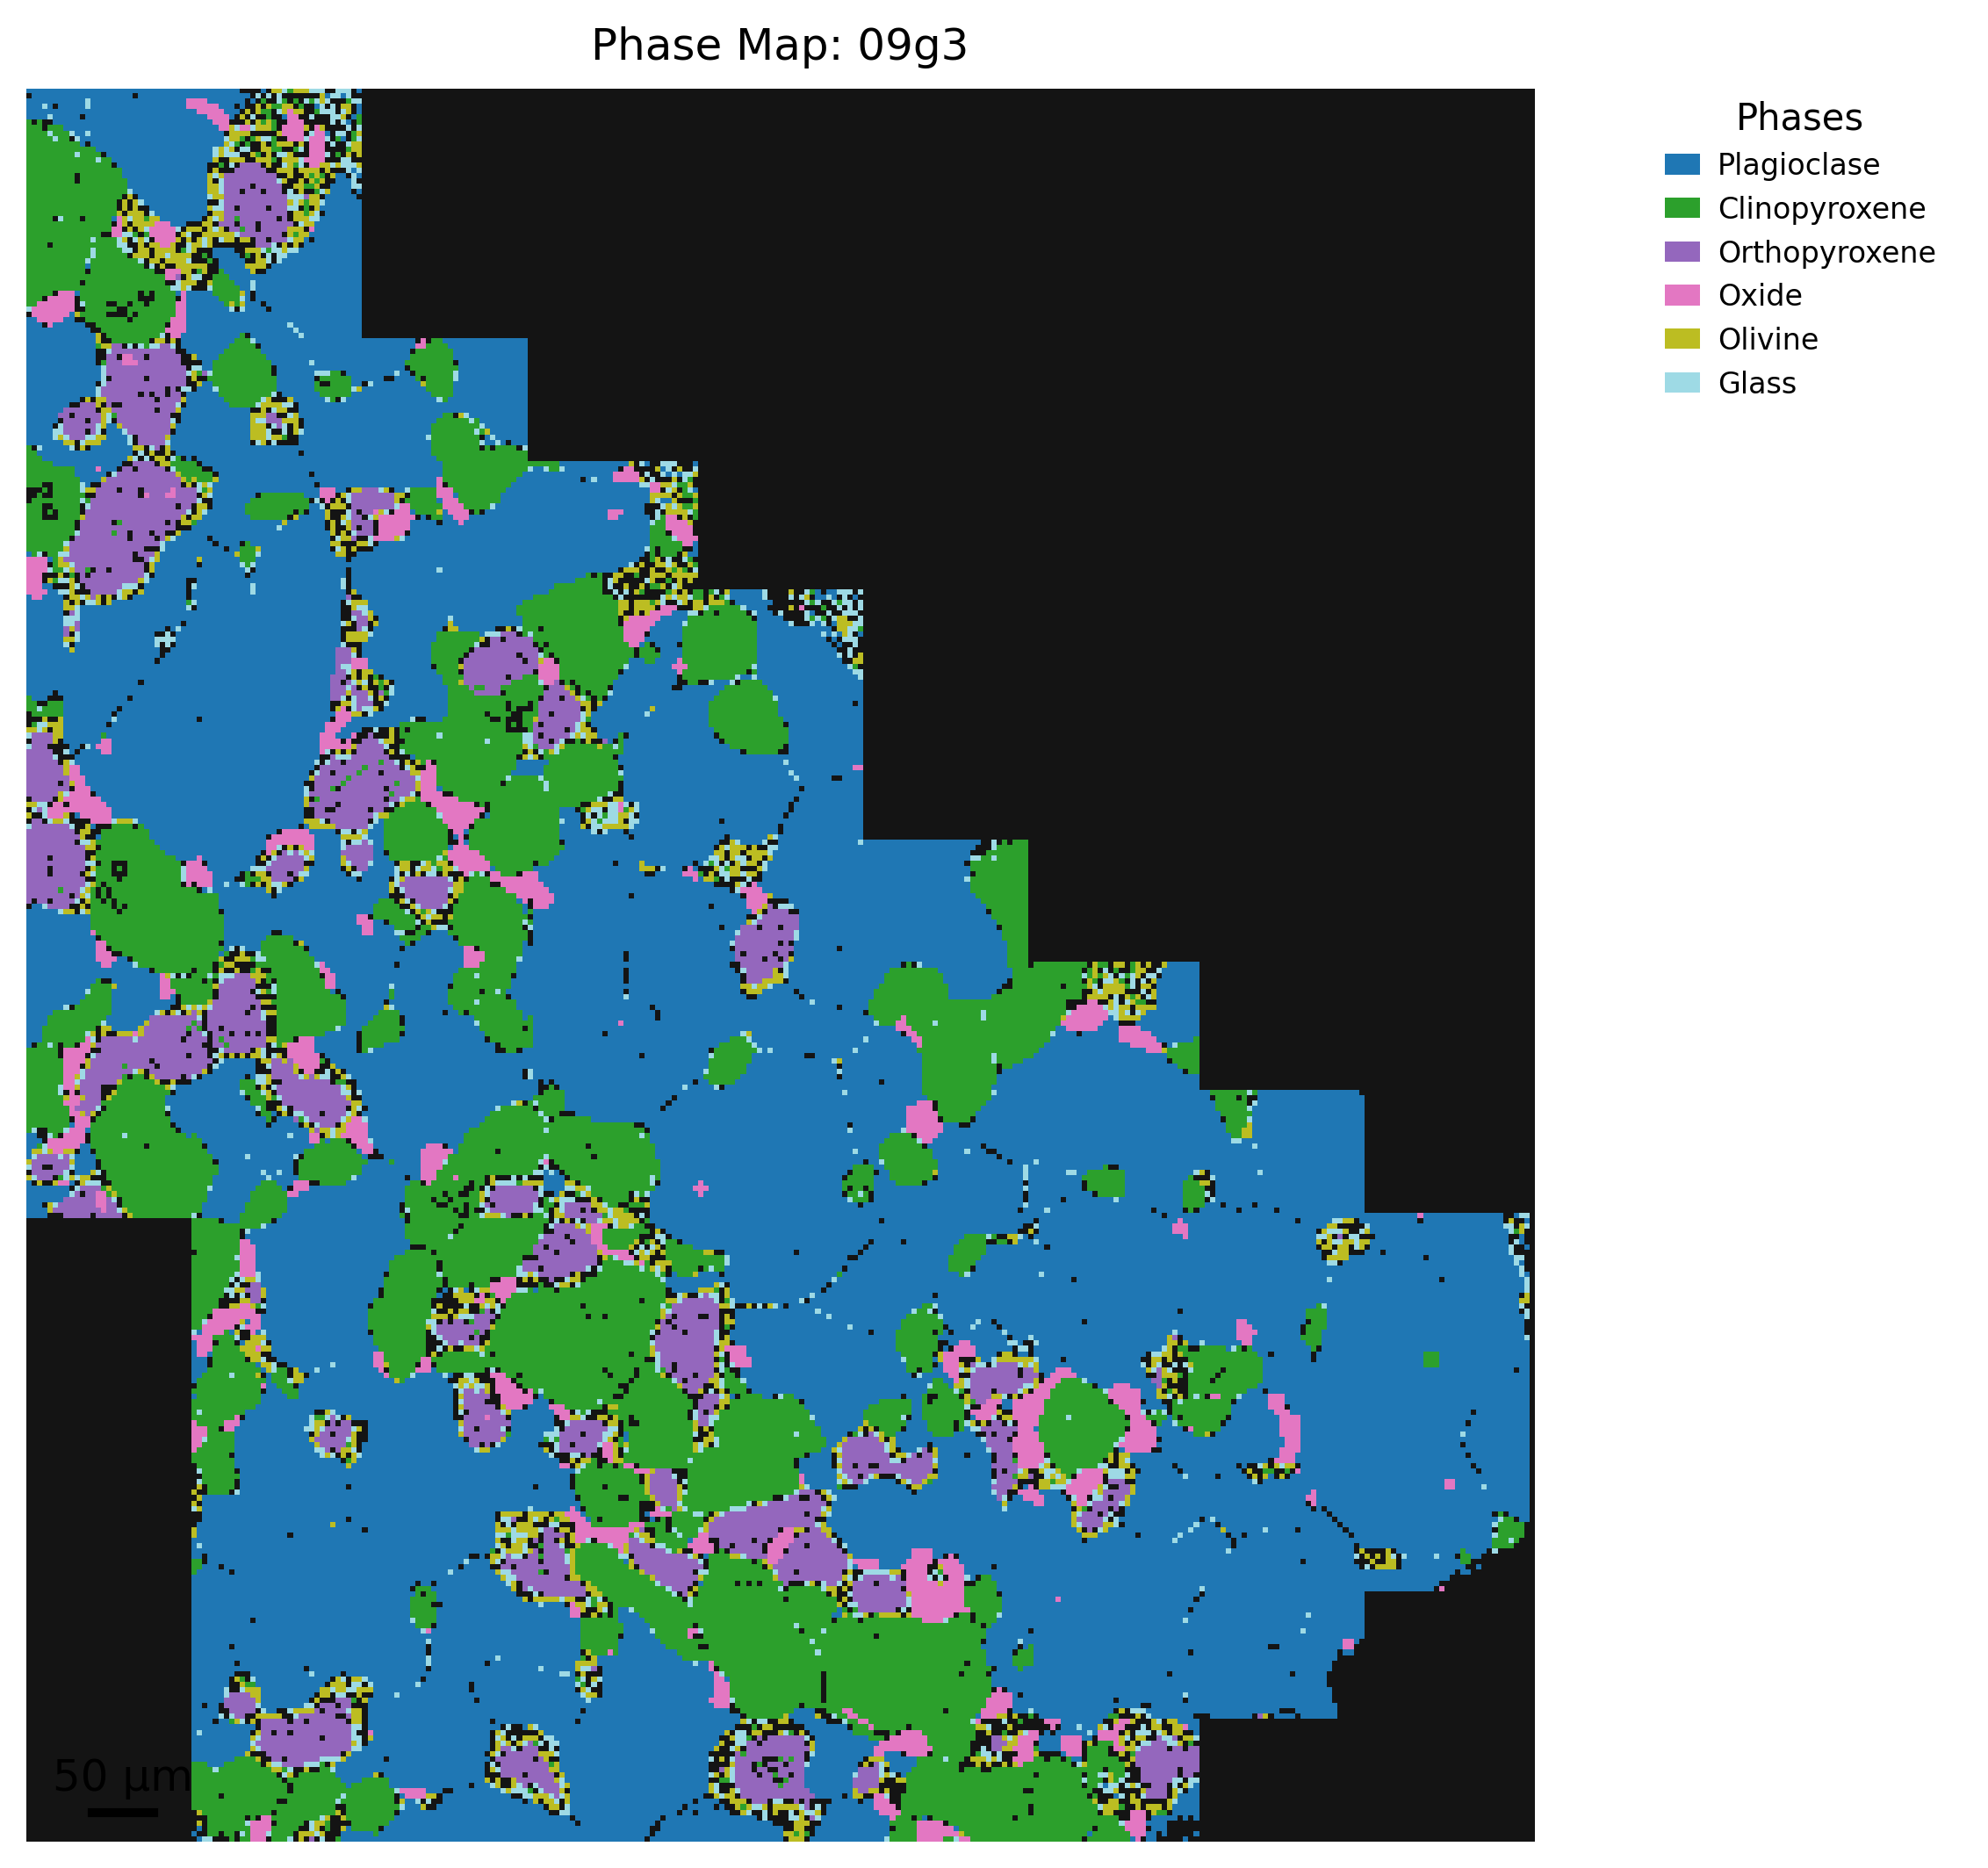

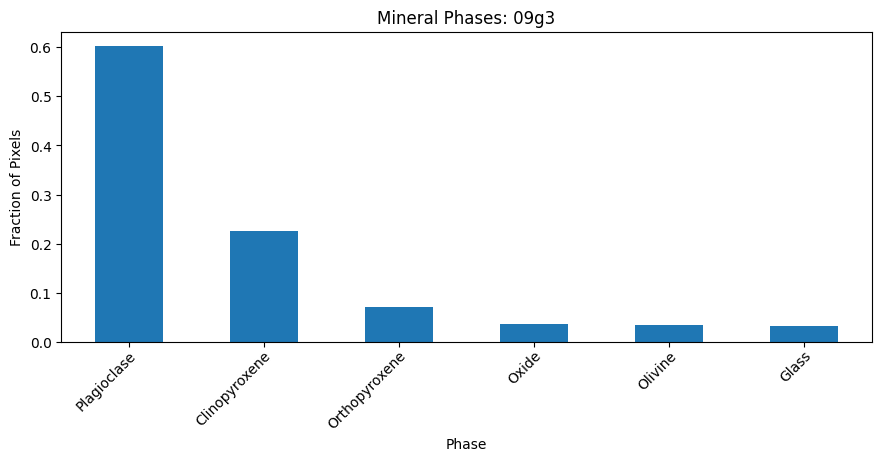

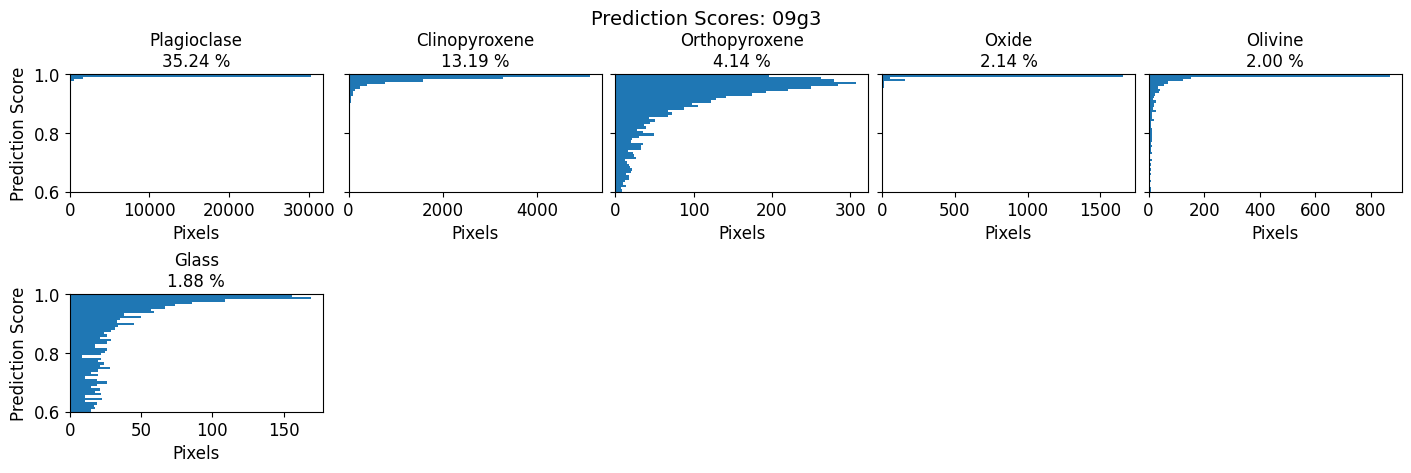

In [4]:
%matplotlib inline

result = mm.run_map(
    "Maps/09g3",
    renormalize=True,
    units="element_wt%",
    pixel_size_um=4.0,
    scalebar_um=50,
    total_threshold=50,
    min_frac=0.01,
)

## 2. Interactive pixel composition picker

`mm.interactive_pixels` displays the phase map and records the full oxide composition of each pixel you click. Each click:
- Places a marker on the map
- Prints the oxide values below the figure
- Appends a row to the dataframe in `controller["picks"]`

**Keybindings:** `r`/`u` undo last pick &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

After quitting, access your picks as a DataFrame:
```python
controller["picks"]
```

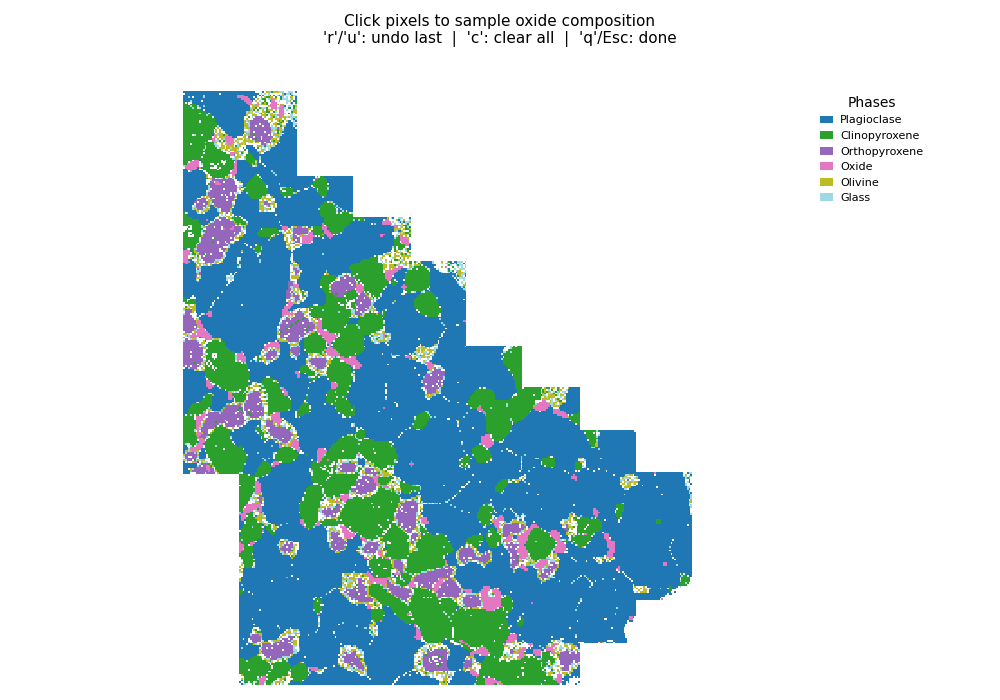

Output()

In [5]:
%matplotlib widget

controller = mm.interactive_pixels(result)

In [6]:
%matplotlib inline

controller["picks"]

,x,y,phase,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,Cr2O3,Total,Total_raw
0,124,157,Plagioclase,51.367018,-0.006697,30.985247,0.178281,0.054904,-0.276354,13.785328,3.329709,0.385735,0.196828,100.0,97.901364
1,114,187,Plagioclase,50.601170,-0.069017,31.962915,0.752068,-0.344107,0.522093,12.172985,4.369740,0.031155,0.000998,100.0,99.420050
2,114,198,Clinopyroxene,50.152360,0.563303,8.634052,6.638671,-0.411241,13.210374,19.702516,1.694756,-0.023997,-0.160793,100.0,94.650700
3,104,218,Orthopyroxene,51.016113,-0.005437,5.669703,15.040290,-0.081305,26.937669,0.654058,0.844517,-0.046604,-0.029004,100.0,92.385606
4,101,235,Clinopyroxene,48.615136,0.687156,7.971798,6.190848,-0.553011,13.864687,21.909731,1.063081,0.259359,-0.008785,100.0,93.319026
5,71,263,Plagioclase,51.806361,-0.209002,31.589375,0.372100,-0.179266,-0.261121,12.349832,4.332151,0.349332,-0.149761,100.0,94.263436


### 2a. Filter to a specific phase

Pass `phase` to restrict the display and clicks to one or more mineral phases. Pixels outside the selected phase are shown as white background.

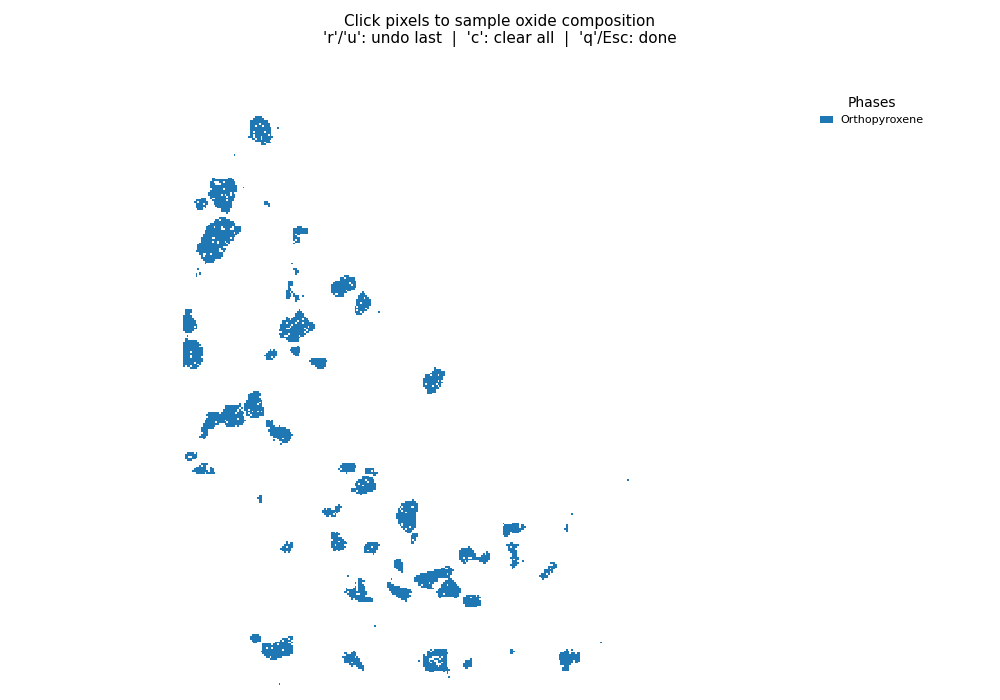

Output()

In [ ]:
%matplotlib widget

controller_opx = mm.interactive_pixels(result, 
                                       phase="Orthopyroxene", # plot only pixels classified as orthopyroxene
                                       )

### 2b. Display an oxide heatmap as background

Pass `oxide_key` to show an oxide or component concentration map instead of the phase map. Combine with `phase` to restrict to a single mineral.

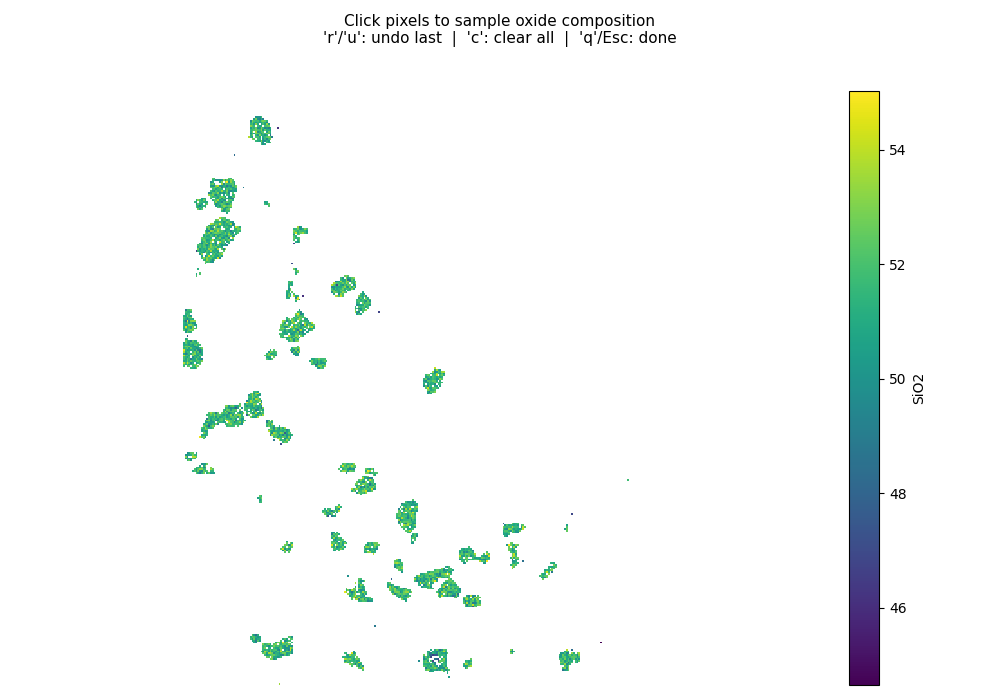

Output()

In [ ]:
%matplotlib widget

controller_sio2 = mm.interactive_pixels(result, oxide_key="SiO2", phase="Orthopyroxene")

## 3. Plot pick locations

`mm.plot_locations` overlays picked pixel locations on a map. Pass `map_key` to use an oxide map as the background.

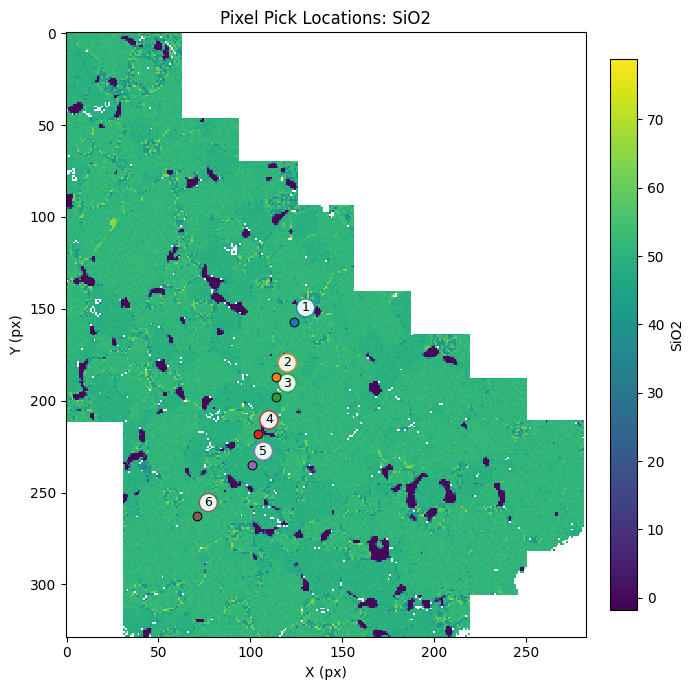

In [ ]:
%matplotlib inline

fig, ax = mm.plot_locations(result, 
                            controller["picks"], # plot only the pixels that have been picked
                            map_key="SiO2", # color the points by their SiO2 content
                            )

## 4. Interactive line profiles

`mm.interactive_line_profile` lets you draw transects across a map by clicking a start and end point. Each completed transect is extracted and plotted immediately.

**Keybindings:** `r` reset current clicks &nbsp;|&nbsp; `u` undo last transect &nbsp;|&nbsp; `c` clear all &nbsp;|&nbsp; `q`/Esc quit

Access results after quitting:
```python
lp["profiles_df"]     # all profile data concatenated
lp["coordinates_df"]  # transect start/end coordinates
```

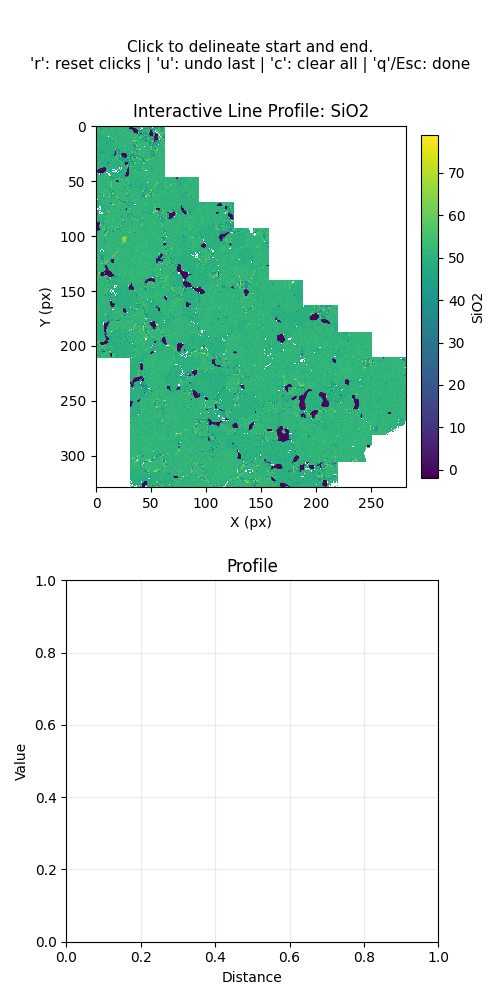

In [ ]:
%matplotlib widget

lp = mm.interactive_line_profile(
    result,
    key="SiO2", # key of the oxide map to plot the line profile for
    method="none", # do not apply any smoothing to the line profile. use mean or median (across the pixel width) for a smoothed profile 
    width_px=5, # width of the line profile in pixels
    pixel_size_um=4.0, # pixel size in micrometers
)

### 4a. Filter transects to a single phase

Pass `phase` to mask the background map to pixels of a specific mineral before drawing transects.

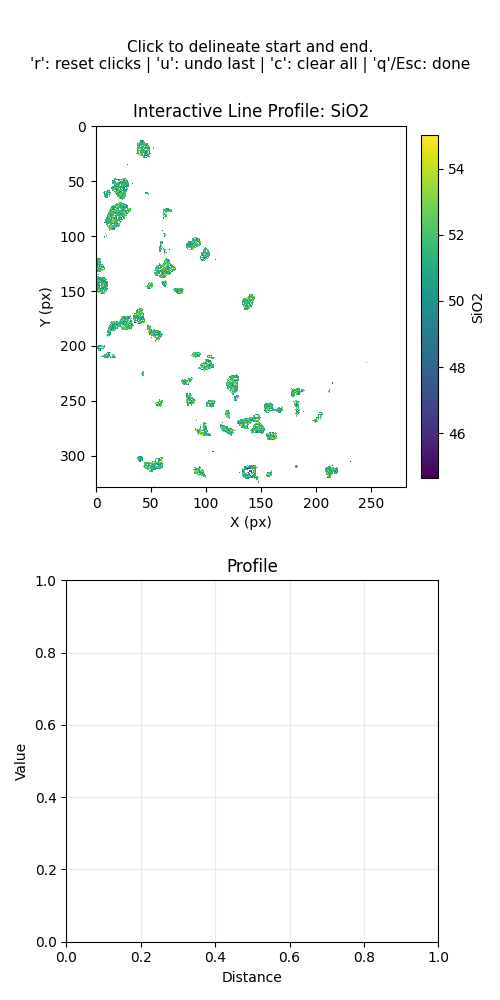

In [15]:
%matplotlib widget

lp_opx = mm.interactive_line_profile(
    result,
    key="SiO2",
    phase="Orthopyroxene",
    method="none",
    width_px=5,
    pixel_size_um=4.0,
)

Return the line profile dataframe. 

In [ ]:
%matplotlib inline
lp["profiles_df"]

,profile_id,distance_px,distance_um,SiO2,SiO2_smoothed,x,y,perp_distance_px,source,width_px,length_px,length_um,color,x0,y0,x1,y1
0,1,0.604119,2.416476,51.142650,51.142650,115.0,120.0,-2.134521,auto,5.0,56.640529,226.562116,#1f77b4,113,119,108,176
1,1,0.684503,2.738013,49.191655,49.191655,114.0,120.0,-1.137757,auto,5.0,56.640529,226.562116,#1f77b4,113,119,108,176
2,1,0.764887,3.059550,50.364050,50.364050,113.0,120.0,-0.140993,auto,5.0,56.640529,226.562116,#1f77b4,113,119,108,176
3,1,0.845272,3.381086,48.432705,48.432705,112.0,120.0,0.855771,auto,5.0,56.640529,226.562116,#1f77b4,113,119,108,176
4,1,0.925656,3.702623,51.488186,51.488186,111.0,120.0,1.852535,auto,5.0,56.640529,226.562116,#1f77b4,113,119,108,176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2,59.590009,238.360036,49.151967,49.151967,82.0,172.0,0.075332,auto,5.0,60.539534,242.158135,#ff7f0e,89,113,82,173
567,2,59.710340,238.841361,49.291353,49.291353,81.0,172.0,1.068066,auto,5.0,60.539534,242.158135,#ff7f0e,89,113,82,173
568,2,59.830672,239.322687,48.284620,48.284620,80.0,172.0,2.060800,auto,5.0,60.539534,242.158135,#ff7f0e,89,113,82,173
569,2,60.342080,241.368320,51.505185,51.505185,84.0,173.0,-2.030467,auto,5.0,60.539534,242.158135,#ff7f0e,89,113,82,173


## 5. Plot transect locations

Pass the `coordinates_df` from a line profile controller to `mm.plot_locations` to visualize transect positions.

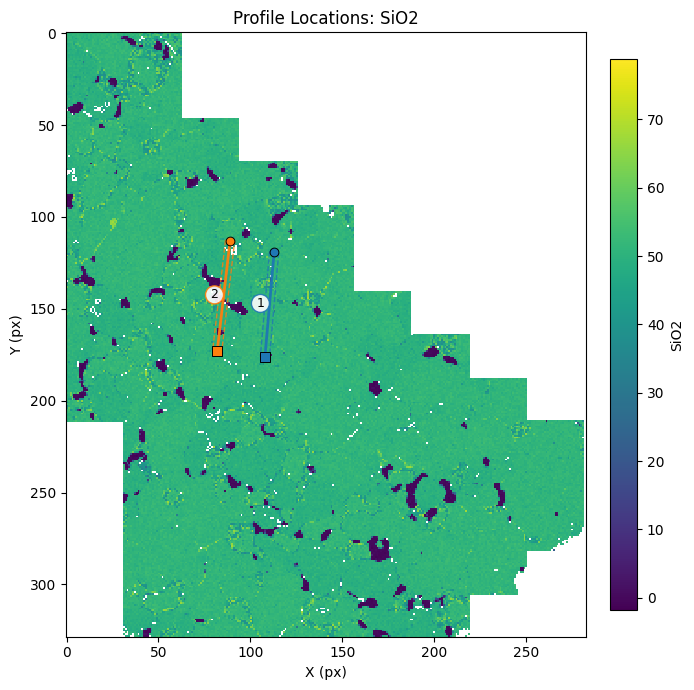

In [ ]:
%matplotlib inline

fig, ax = mm.plot_locations(result, 
                            lp["coordinates_df"],
                            map_key="SiO2"
                            )

## 6. Batch extract profiles from saved transects

`mm.batch_extract_line_profiles` extracts profiles for multiple oxides at once from a saved transect table. Pass `lp["coordinates_df"]` from an interactive session, or any DataFrame with `x0`, `y0`, `x1`, `y1` columns.

Each oxide becomes its own column, making it easy to compare compositions along the same transect.

In [ ]:
%matplotlib inline

profiles_df = mm.batch_extract_line_profiles(
    result,
    transects=lp["coordinates_df"],
    keys=["SiO2", "Al2O3", "FeOt", "MgO", "CaO"],
    method="mean",
    pixel_size_um=4.0,
)

profiles_df

In [ ]:
# Long format — one row per oxide per distance bin, useful for plotting
profiles_df, profiles_long_df = mm.batch_extract_line_profiles(
    result,
    transects=lp["coordinates_df"],
    keys=["SiO2", "MgO", "CaO"],
    method="mean",
    pixel_size_um=4.0,
    return_long=True,
)

profiles_long_df

## 7. Composite component map

`mm.plot_component_composite` overlays continuous solid-solution compositions (e.g. plagioclase An%, olivine Fo%, pyroxene XMg) on top of a categorical phase map. This gives a single figure showing both phase identity and mineral chemistry.

The component maps are computed automatically by `run_map` and stored in `result["component_maps"]`.

In [ ]:
%matplotlib inline

fig, mineral_map, comp_maps = mm.plot_component_composite(
    result,
    title="09g3 Composite",
    pixel_size_um=4.0,
    scalebar_um=50,
)

You can restrict which phases appear and adjust the color limits. `limits_mode="percentile"` clips the colorbar to the 5th–95th percentile of each component, which is useful when a few extreme pixels would otherwise compress the color scale.

In [ ]:
fig, mineral_map, comp_maps = mm.plot_component_composite(
    result,
    title="09g3 Composite (percentile limits)",
    pixel_size_um=4.0,
    scalebar_um=50,
    limits_mode="percentile",
    percentile=(5, 95),
    phases=["Plagioclase", "Orthopyroxene", "Olivine", "Amphibole"],
)